In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [17]:
video_path = "schooling-datasets/fish_30.mp4"
output_path = "schooling-datasets/upscaled_fish_30.mp4"
scale = 4

cap = cv.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
n_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

# Create VideoWriter for upscaled frames
fourcc = cv.VideoWriter_fourcc(*"mp4v")
upscaled_size = (width * scale, height * scale)
writer = cv.VideoWriter(
    output_path,
    fourcc,
    fps,
    upscaled_size,
    True,  # If grayscale, set to False
)

frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    upscaled = cv.resize(
        frame, 
        None, 
        fx=scale, 
        fy=scale, 
        interpolation=cv.INTER_LANCZOS4
    )
    writer.write(upscaled)
    frame_idx += 1
    if frame_idx % 25 == 0 or frame_idx == n_frames:
        print(f"  upscaled {frame_idx}/{n_frames} frames")

cap.release()
writer.release()
print(f"Saved {scale}x upscaled video to {output_path}")

  upscaled 25/3030 frames
  upscaled 50/3030 frames
  upscaled 75/3030 frames
  upscaled 100/3030 frames
  upscaled 125/3030 frames
  upscaled 150/3030 frames
  upscaled 175/3030 frames
  upscaled 200/3030 frames
  upscaled 225/3030 frames
  upscaled 250/3030 frames
  upscaled 275/3030 frames
  upscaled 300/3030 frames
  upscaled 325/3030 frames
  upscaled 350/3030 frames
  upscaled 375/3030 frames
  upscaled 400/3030 frames
  upscaled 425/3030 frames
  upscaled 450/3030 frames
  upscaled 475/3030 frames
  upscaled 500/3030 frames
  upscaled 525/3030 frames
  upscaled 550/3030 frames
  upscaled 575/3030 frames
  upscaled 600/3030 frames
  upscaled 625/3030 frames
  upscaled 650/3030 frames
  upscaled 675/3030 frames
  upscaled 700/3030 frames
  upscaled 725/3030 frames
  upscaled 750/3030 frames
  upscaled 775/3030 frames
  upscaled 800/3030 frames
  upscaled 825/3030 frames
  upscaled 850/3030 frames
  upscaled 875/3030 frames
  upscaled 900/3030 frames
  upscaled 925/3030 frames
  up

In [4]:
import cv2 as cv
import numpy as np

# We want to extend the duration of the video by 4x using smooth slow-motion: 
# for every pair of consecutive frames, we will generate 3 intermediate frames using optical flow.

input_path = 'schooling-datasets/upscaled_fish_30.mp4'     # upscaled video
output_slowmo_path = 'schooling-datasets/slowmo_fish_30.mp4'  # will be overwritten with the 4x slow-motion video

cap = cv.VideoCapture(input_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {input_path}")

fps = cap.get(cv.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))

fourcc = cv.VideoWriter_fourcc(*"mp4v")
writer = cv.VideoWriter(
    output_slowmo_path,
    fourcc,
    fps,
    (int(width), int(height)),
    True,
)

# Read all frames
frames = []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frames.append(frame)
cap.release()

if len(frames) < 2:
    raise RuntimeError(f"Need at least 2 frames to perform slow motion using optical flow.")

def interpolate_frame(frame1, frame2, alpha):
    """Interpolate between frame1 and frame2 using optical flow and alpha (0:frame1, 1:frame2)"""
    # Convert to gray for optical flow
    prev_gray = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)
    next_gray = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

    flow = cv.calcOpticalFlowFarneback(
        prev_gray, next_gray, None, 
        pyr_scale=0.5, levels=3, winsize=15, iterations=3,
        poly_n=5, poly_sigma=1.2, flags=0
    )

    # Calculate mapping for interpolation
    h, w = prev_gray.shape
    flow_x, flow_y = flow[..., 0], flow[..., 1]
    dx = alpha * flow_x
    dy = alpha * flow_y
    map_x, map_y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = (map_x + dx).astype(np.float32)
    map_y = (map_y + dy).astype(np.float32)
    warped1 = cv.remap(frame1, map_x, map_y, cv.INTER_LINEAR)

    rev_dx = (1.0 - alpha) * (-flow_x)
    rev_dy = (1.0 - alpha) * (-flow_y)
    rev_map_x = (map_x + rev_dx).astype(np.float32)
    rev_map_y = (map_y + rev_dy).astype(np.float32)
    warped2 = cv.remap(frame2, rev_map_x, rev_map_y, cv.INTER_LINEAR)

    # Blend the two warped frames
    interp = cv.addWeighted(warped1, 1 - alpha, warped2, alpha, 0)
    return interp

for i in range(len(frames)-1):
    frame_a = frames[i]
    frame_b = frames[i+1]
    # Write the original frame
    writer.write(frame_a)
    # Write 3 synthetic frames using optical flow
    for step in [0.25, 0.50, 0.75]:
        interp = interpolate_frame(frame_a, frame_b, step)
        writer.write(interp)

# Write the final frame (not to be skipped)
writer.write(frames[-1])

writer.release()
print(f"Saved fluid slow-motion (4x duration) video to {output_slowmo_path}")

Saved fluid slow-motion (4x duration) video to schooling-datasets/slowmo_fish_30.mp4


In [5]:
# Apply black-hat on raw grayscale frames (no background subtraction here)

video_path = "schooling-datasets/upscaled_fish_30.mp4"
output_path = "schooling-datasets/blackhat_fish_30.mp4"

cap = cv.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

kernel_size = 9
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (kernel_size, kernel_size))

writer = None
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    blackhat = cv.morphologyEx(gray, cv.MORPH_BLACKHAT, kernel)

    if writer is None:
        h, w = blackhat.shape
        writer = cv.VideoWriter(
            output_path,
            cv.VideoWriter_fourcc(*"mp4v"),
            cap.get(cv.CAP_PROP_FPS),
            (w, h),
            False,
        )

    writer.write(blackhat)
    frame_count += 1

cap.release()
if writer is not None:
    writer.release()

print(f"Saved {frame_count} black-hat frames to {output_path}")

Saved 3030 black-hat frames to schooling-datasets/blackhat_fish_30.mp4


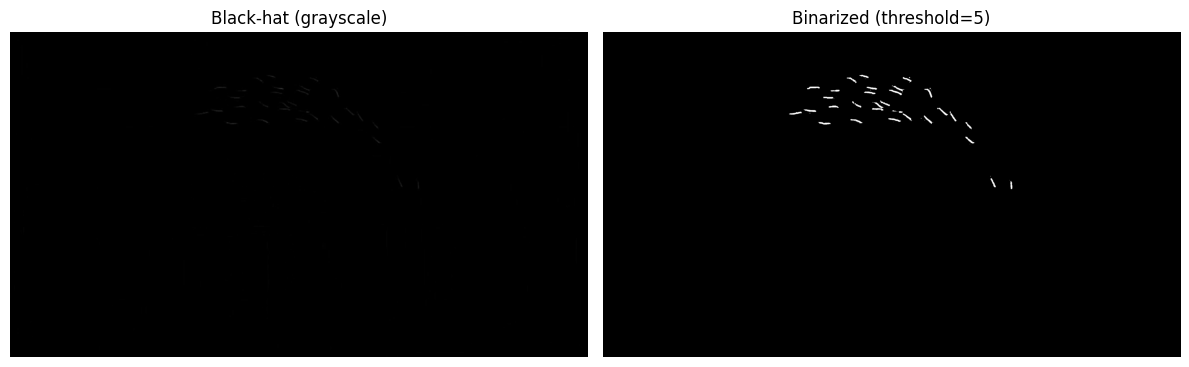

white pixels=9335
Saved 3030 binarized black-hat frames to schooling-datasets/blackhat_binarized_fish_30.mp4


In [6]:
def binarize_blackhat(
    blackhat: np.ndarray,
    *,
    threshold: int = 5,
    close_kernel: int = 3,
) -> np.ndarray:
    """Binarize black-hat: black background, solid white fish."""
    if blackhat.ndim == 3:
        gray = cv.cvtColor(blackhat, cv.COLOR_BGR2GRAY)
    else:
        gray = blackhat

    _, binary = cv.threshold(gray, threshold, 255, cv.THRESH_BINARY)

    if close_kernel > 1:
        k = cv.getStructuringElement(cv.MORPH_ELLIPSE, (close_kernel, close_kernel))
        binary = cv.morphologyEx(binary, cv.MORPH_CLOSE, k)

    return binary


THRESHOLD = 5  # lower = more fish pixels; try 4-8

cap = cv.VideoCapture("schooling-datasets/blackhat_fish_30.mp4")
ret, blackhat_frame = cap.read()
cap.release()
if not ret:
    raise RuntimeError("Run cell 1 first to create blackhat_30fish.mp4")

binary = binarize_blackhat(blackhat_frame, threshold=THRESHOLD)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(blackhat_frame, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Black-hat (grayscale)")
axes[0].axis("off")
axes[1].imshow(binary, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Binarized (threshold={THRESHOLD})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"white pixels={np.sum(binary == 255)}")

output_path = "schooling-datasets/blackhat_binarized_fish_30.mp4"
cap = cv.VideoCapture("schooling-datasets/blackhat_fish_30.mp4")
fourcc = cv.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
writer = cv.VideoWriter(output_path, fourcc, fps, (width, height), isColor=False)

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    binary = binarize_blackhat(frame, threshold=THRESHOLD)
    writer.write(binary)
    frame_count += 1

cap.release()
writer.release()
print(f"Saved {frame_count} binarized black-hat frames to {output_path}")